In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('./resume_classified_dataset.csv')


In [29]:
df.head()

,resume_id,resume_text,category
0,1,Name: Abiral Pandey Email: abiral.pandey88@gma...,Software Engineer
1,2,Achyuth 540-999-8048 achyuth.java88@gmail.com ...,Software Engineer
2,3,"Adelina Erimia, PMP, Six Sigma Green Belt, SMC...",Business Analyst
3,4,Adhi Gopalam adhigopalam@gmail.com 281-212-359...,Business Analyst
4,5,Ajay Kumar (CSM) Email/Skype: ajaydt@gmail.com...,Business Analyst


In [30]:
df.shape

(224, 3)

## Exploring categories

In [31]:
df['category'].value_counts()

category
Business Analyst     114
Web Developer         59
Software Engineer     39
Finance                9
DevOps Engineer        3
Name: count, dtype: int64

C:\Users\vedan\AppData\Local\Temp\ipykernel_23052\1953304837.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['category'], palette="Set2")


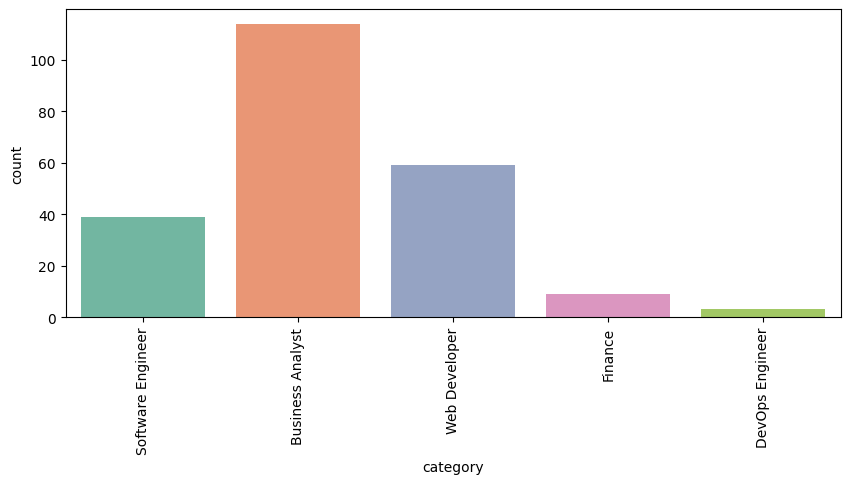

In [32]:
plt.figure(figsize=(10,4))
sns.countplot(x = df['category'], palette="Set2")
plt.xticks(rotation= 90)
plt.show()

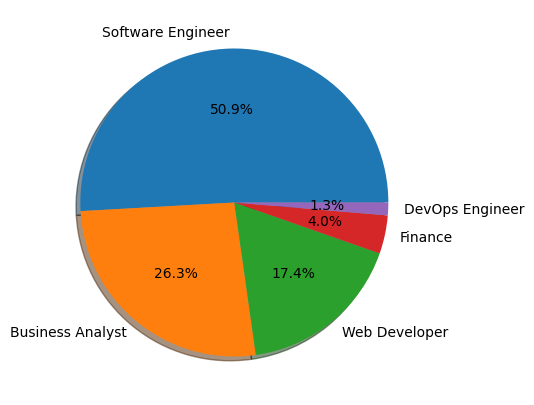

In [33]:
counts = df['category'].value_counts()
labels = df['category'].unique()

plt.figure(figsize= (10,5))
plt.pie(counts, labels=labels, autopct= '%0.1f%%', shadow= True)
plt.show()

## Exploring Resume

In [34]:
df['resume_text'][1]

"Achyuth 540-999-8048 achyuth.java88@gmail.com OBJECTIVE: Around 8 years of strong software experience in design, development, analysis and deployment of web-based and Client-Server business applications using Object Oriented Analysis and Design (OOAD, OOPS) and Java/JEE/J2EE technologies in Financial, Insurance, and Health Sector Domain with Software Development Life Cycle (SDLC). PROFESSIONAL SUMMARY: Actively involved in each phase of Software Development Life cycle (SDLC). Expertise in client scripting language and server scripting languages like HTML5, CSS3, JavaScript, JQuery, Ajax, AngularJS, NodeJS, JSON, Bootstrap. Utilized Java 1.8 features like Lambda expressions and Stream API for Bulk data operations on Collections which would increase the performance of the Application Hands on experience with Amazon web services (AWS) and Amazon cloud technologies such as Amazon EC2 (virtual servers) and Amazon Cloud Watch (monitoring). Managed Amazon Web Services like EC2, S3 bucket, EL

In [35]:
import re

def cleanResume(txt):
    
    # remove URLs
    cleanTxt = re.sub(r'http\S+|www\S+', ' ', txt)
    
    # remove emails
    cleanTxt = re.sub(r'\S+@\S+', ' ', cleanTxt)
    
    # remove hashtags and mentions
    cleanTxt = re.sub(r'#\S+|@\S+', ' ', cleanTxt)
    
    # remove newline characters
    cleanTxt = re.sub(r'\n', ' ', cleanTxt)
    
    # remove special characters and punctuation
    cleanTxt = re.sub(r'[^A-Za-z0-9 ]+', ' ', cleanTxt)
    
    # remove extra spaces
    cleanTxt = re.sub(r'\s+', ' ', cleanTxt).strip()
    
    return cleanTxt


In [36]:
cleanResume(' heyy my #hello      name is aayushi visit    my website http://aayushi and email @aayushi123 happy day')

'heyy my name is aayushi visit my website and email happy day'

In [37]:
df['resume_text'] = df['resume_text'].apply(lambda x: cleanResume(x))

In [38]:
df['resume_text'][1]

'Achyuth 540 999 8048 OBJECTIVE Around 8 years of strong software experience in design development analysis and deployment of web based and Client Server business applications using Object Oriented Analysis and Design OOAD OOPS and Java JEE J2EE technologies in Financial Insurance and Health Sector Domain with Software Development Life Cycle SDLC PROFESSIONAL SUMMARY Actively involved in each phase of Software Development Life cycle SDLC Expertise in client scripting language and server scripting languages like HTML5 CSS3 JavaScript JQuery Ajax AngularJS NodeJS JSON Bootstrap Utilized Java 1 8 features like Lambda expressions and Stream API for Bulk data operations on Collections which would increase the performance of the Application Hands on experience with Amazon web services AWS and Amazon cloud technologies such as Amazon EC2 virtual servers and Amazon Cloud Watch monitoring Managed Amazon Web Services like EC2 S3 bucket ELB Auto Scaling SNS SQS AMI IAM Dynamo DB Elastic search Vi

## Words into categorical values

In [39]:
df['category'].unique()

<ArrowStringArray>
['Software Engineer',  'Business Analyst',     'Web Developer',
           'Finance',   'DevOps Engineer']
Length: 5, dtype: str

In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# le.fit(df['category'])

# df['category'] = le.transform(df['category'])

df['category'] = le.fit_transform(df['category'])

In [41]:
df

,resume_id,resume_text,category
0,1,Name Abiral Pandey Email Phone 940 242 3303 Cu...,3
1,2,Achyuth 540 999 8048 OBJECTIVE Around 8 years ...,3
2,3,Adelina Erimia PMP Six Sigma Green Belt SMC 46...,0
3,4,Adhi Gopalam 281 212 3592 Certified Scrum Mast...,0
4,5,Ajay Kumar CSM Email Skype Mob 1 847 899 4194 ...,0
...,...,...,...
219,220,Sanjay Email Contact 1 203 200 7335 Profession...,4
220,221,Srinivas 315 221 3723 OBJECTIVE Technically sk...,3
221,222,VEMA REDDY SR JAVA DEVELOPER PH 865 375 0056 E...,3
222,223,Professional Summary 8 years of IT experience ...,4


In [42]:
df['category'].unique()

array([3, 0, 4, 2, 1])

## Vactorization

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

required_text= tfidf.fit_transform(df['resume_text'])

In [44]:
df

,resume_id,resume_text,category
0,1,Name Abiral Pandey Email Phone 940 242 3303 Cu...,3
1,2,Achyuth 540 999 8048 OBJECTIVE Around 8 years ...,3
2,3,Adelina Erimia PMP Six Sigma Green Belt SMC 46...,0
3,4,Adhi Gopalam 281 212 3592 Certified Scrum Mast...,0
4,5,Ajay Kumar CSM Email Skype Mob 1 847 899 4194 ...,0
...,...,...,...
219,220,Sanjay Email Contact 1 203 200 7335 Profession...,4
220,221,Srinivas 315 221 3723 OBJECTIVE Technically sk...,3
221,222,VEMA REDDY SR JAVA DEVELOPER PH 865 375 0056 E...,3
222,223,Professional Summary 8 years of IT experience ...,4


## Train test splitting

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(required_text, df['category'], test_size= 0.2, random_state=42)
# x = required_text, y = category

In [46]:
X_train.shape

(179, 14676)

In [47]:
X_test.shape

(45, 14676)

## lets train the model and print the classification report

In [48]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score


clf = OneVsRestClassifier(KNeighborsClassifier())

clf.fit(X_train,y_train)
ypred = clf.predict(X_test)
print(ypred)
print(accuracy_score(y_test,ypred)) 

[0 0 0 4 3 4 0 0 4 4 0 0 3 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 4 0 4 0 3 3 0 4 4
 0 0 0 0 4 0 0 0]
0.8444444444444444


## Prediction System

In [ ]:
import pickle
pickle.dump(tfidf,open('tfidf.pkl', 'wb'))
pickle.dump(clf, open('clf.pkl', 'wb'))
# pickle.dump(le, open('label_encoder.pkl', 'wb'))

In [50]:
my_resume = """Name Stephen Ruiz Contact Information Email Phone 001 199 087 5645x74170 Address USCGC Gomez FPO AP 96375 LinkedIn 
linkedin com in stephenruiz Professional Summary Results driven Finance with 4 years of experience in delivering high quality solutions 
collaborating with cross functional teams and driving organizational growth through innovative problem solving Education Master of 
Business Administration from Carpenter LLC University with a GPA of 7 08 10 Technical Skills Budgeting Accounting Forecasting Excel 
Financial Analysis Taxation Professional Experience Worked at Mclean LLC 2016 2025 as a Finance Managed projects involving Excel 
Forecasting Accounting Collaborated with stakeholders to improve productivity and operational efficiency Delivered measurable business 
outcomes and optimized workflows Worked at Long LLC 2021 2024 as a Finance Managed projects involving Taxation Auditing Financial 
Analysis Collaborated with stakeholders to improve productivity and operational efficiency Delivered measurable business outcomes 
and optimized workflows Worked at Miller Gill and Rivera 2019 2026 as a Finance Managed projects involving Accounting Auditing Budgeting 
Collaborated with stakeholders to improve productivity and operational efficiency Delivered measurable business outcomes and optimized 
workflows Projects Implemented predictive analytics models for sales forecasting Designed and implemented a dashboard for real time 
business analytics Developed a secure authentication system with multi factor authentication Certifications Google Data Analytics 
Professional Certificate Scrum Master Certification Achievements Achieved employee excellence award at Thompson Strong and Alexander 
Led a team of 6 professionals to successful project completion Increased process efficiency by 44 Soft Skills Leadership Team Collaboration 
Communication Problem Solving Time Management Languages English Hindi"""

In [51]:
import pickle

# load the trained classifier
clf = pickle.load(open('clf.pkl', 'rb'))

# clean the input resume
cleaned_resume = cleanResume(my_resume)

# transform the cleaned resume using trained tfidfvectoriser
input_features = tfidf.transform([cleaned_resume])

# make the prediction using the loaded classifier
prediction_id = clf.predict(input_features)[0]

# category mapping
category_mapping = {
    0: "Business Analyst",
    1: "DevOps Engineer",
    2: "Finance",
    3: "Software Engineer",
    4: "Web Developer"
}

category_name = category_mapping.get(prediction_id, "Unknown")
print("category name: ", category_name)
print(prediction_id)


category name:  Business Analyst
0
